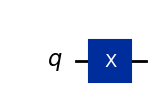

In [57]:
from qiskit import QuantumCircuit

qc = QuantumCircuit(1)
qc.x(0)
qc.draw("mpl")

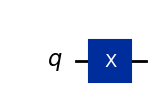

In [58]:
from qiskit import QuantumCircuit

qc = QuantumCircuit(1)
qc.x(0)
qc.draw("mpl")

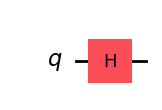

In [59]:
qc = QuantumCircuit(1)
qc.h(0)
qc.draw("mpl")

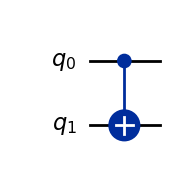

In [60]:
qc = QuantumCircuit(2)
qc.cx(0, 1) # |10> -> |11> / |11> -> |10>
qc.draw("mpl")

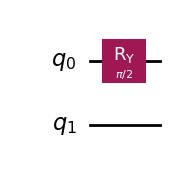

In [61]:
import numpy as np

pi = np.pi

qc = QuantumCircuit(2)
qc.ry(pi / 2, 0) # ROTATE THE STATES ABOUT THE Y-AXIS
qc.draw("mpl")

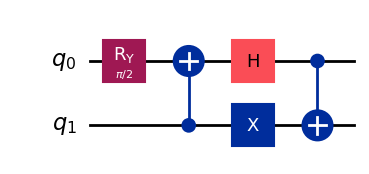

In [62]:
qc=QuantumCircuit(2)
qc.ry(pi/2,0)
qc.cx(1,0)
qc.x(1)
qc.h(0)
qc.cx(0,1)
qc.draw("mpl")

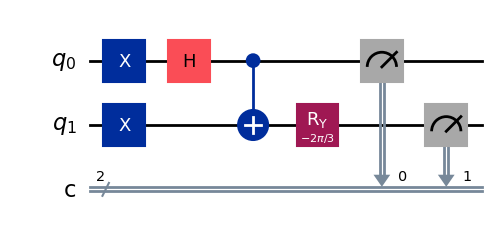

In [63]:
from qiskit.visualization import plot_histogram
from qiskit import ClassicalRegister, QuantumRegister

qr = QuantumRegister(2, "q")
cr = ClassicalRegister(2, "c")
qc1 = QuantumCircuit(qr, cr)

# We know from our analysis above that we need an X gate acting on each of the qubits (L and R)
qc1.x([0, 1])
# We need a Hadamard gate acting on Lucas's qubit, which we're calling the 0th qubit.
qc1.h(0)
# The controlled-NOT gate uses the 0th qubit (Lucas's) as the control and the 1st qubit (Rihanna's)
# as the target.
qc1.cx(0, 1)
# The rotation gate acts on the 1st qubit (Rihanna's) and has an argument of -2 pi/3
qc1.ry(-2 * pi / 3, 1)
# Finally, we want to measure all the qubits in the circuit to obtain measurement probabilities, and
# store the results in the classical bits.
qc1.measure([0, 1], [0, 1])
# Now we can draw the first of the three circuits that will check Bell's inequality for us.
qc1.draw(output="mpl")

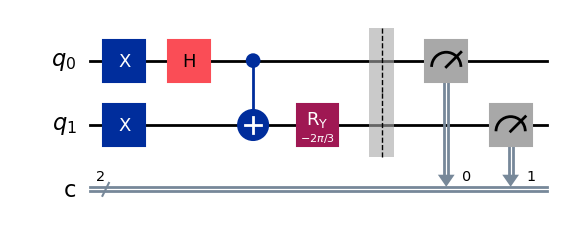

In [64]:
qcs = [QuantumCircuit(2, 2), QuantumCircuit(2, 2), QuantumCircuit(2, 2)]
for i in range(0, len(qcs)):
    qcs[i].x([0, 1])
    qcs[i].h(0)
    qcs[i].cx(0, 1)


qcs[0].ry(-2 * pi / 3, 1)
qcs[1].ry(-4 * pi / 3, 1)
qcs[2].ry(-2 * pi / 3, 1)
qcs[2].ry(-4 * pi / 3, 1) # QCS[2] ROTATING 0 DEGREES

for i in range(0, len(qcs)):
    qcs[i].barrier()
    qcs[i].measure([0, 1], [0, 1])

counts_list = [None] * len(qcs)

qcs[0].draw(output="mpl")

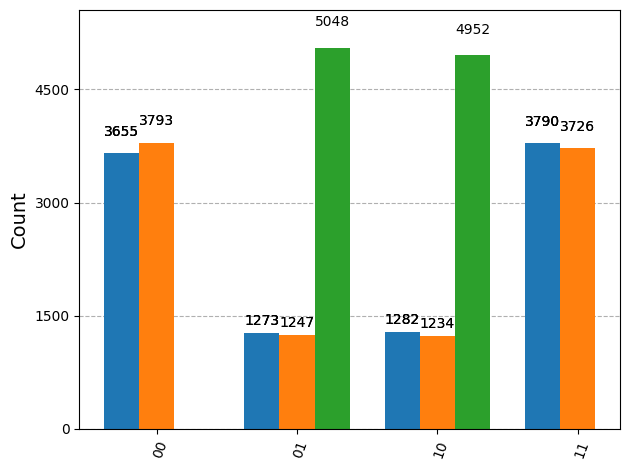

In [65]:
from qiskit.primitives import StatevectorSampler

sampler = StatevectorSampler()

# Start a job that will return shots for all 100 parameter value sets.
for i in range(0, len(qcs)):
    pub = qcs[i]
    job = sampler.run([pub], shots=10000)
    # Extract the result for the 0th pub (this example only has one pub).
    result = job.result()
    data_pub = result[0].data
    counts = data_pub.c.get_counts()
    counts_list[i] = counts
#    plot_histogram(counts)

plot_histogram(counts_list)

{'00': 7448, '01': 7568, '10': 7468, '11': 7516}


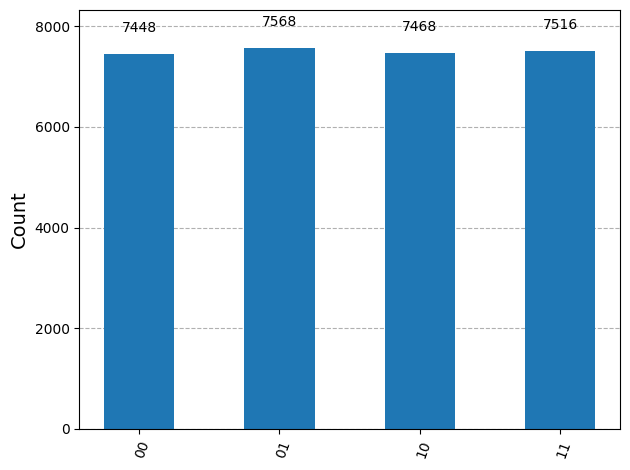

In [66]:
outcomes = ("00", "01", "10", "11")

# Here we convert "None"s into 0's so that we can sum.

for i in range(0, len(qcs)):
    for j in range(0, len(outcomes)):
        if counts_list[i].get(outcomes[j]) is None:
            counts_list[i].update({outcomes[j]: 0})

# Here we create a dictionary that holds all the outcomes and sums over their appearances
# in each of the circuits.

total_counts = {}
for i in range(0, len(outcomes)):
    total_counts[outcomes[i]] = sum(
        counts_list[j].get(outcomes[i]) for j in range(0, len(qcs))
    )

print(total_counts)
plot_histogram(total_counts) # 00 + 11 = 15,019 == 50%

In [67]:
from qiskit_ibm_runtime import QiskitRuntimeService

# Set to True to run on real IBM hardware, False to run locally on a noisy Aer simulator.
USE_HARDWARE = False

# Syntax for first saving your token. Delete these lines after saving your credentials.
# QiskitRuntimeService.save_account(channel='ibm_quantum_platform',
# instance = '<YOUR_IBM_INSTANCE_CRN>', token='<YOUR-API_KEY>', overwrite=True, set_as_default=True)
# service = QiskitRuntimeService(channel='ibm_quantum_platform')

# Load saved credentials
if USE_HARDWARE:
    service = QiskitRuntimeService()

    backend = service.least_busy(
        operational=True, min_num_qubits=qcs[0].num_qubits, simulator=False
    )

else:
    # No account needed: a snapshot of the real ibm_brisbane device, carrying its 127 qubits,
    # real basis gates, real coupling map and real error rates. Everything below transpiles
    # against this target exactly as it would against the hardware one.
    from qiskit_ibm_runtime.fake_provider import FakeBrisbane

    backend = FakeBrisbane()

print(backend.name)


fake_brisbane


In [68]:
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

target = backend.target
pm = generate_preset_pass_manager(target=target, optimization_level=3)

qcs_isa = qcs

for i in range(0, len(qcs)):
    qcs_isa[i] = pm.run(qcs[i])
    qcs_isa[i].draw(output="mpl", idle_wires=False, style="iqp")

    qcs_isa[2].draw(output="mpl", idle_wires=False, style="iqp")

In [69]:
if USE_HARDWARE:
    from qiskit_ibm_runtime import SamplerV2 as Sampler
    # from qiskit_ibm_runtime import Session
    # sampler.options.default_shots = 1000

    # Start a job that will return shots for all 100 parameter value sets.
    # The best practice is to use a session as shown below. This is available to Premium Plan, Flex
    # Plan, and On-Prem (IBM Quantum Platform API) Plan users.
    # result_list = [None] * len(qcs)
    # real_counts_list = [None] * len(qcs)
    # with Session(backend=backend) as session:
    #    sampler = Sampler(mode=session)

    #    for i in range(0, len(qcs)):
    #        # Define the primitive unified bloc (pub)
    #        pub = qcs[i]
    #        job = sampler.run([pub], shots=10000)
    #        # Extract the result for the 0th pub (this example only has one pub).
    #        result_list[i] = job.result()
    #        data_pub = result_list[i][0].data
    #        counts = data_pub.c.get_counts()
    #        real_counts_list[i] = counts
    #    #   plot_histogram(counts)

    # Open users can still carry out this experiment, but without reserving a session of use, meaning
    # repeated queuing is possible.
    from qiskit_ibm_runtime import Batch

    batch = Batch(backend=backend)
    sampler = Sampler(mode=batch)

    result_list = [None] * len(qcs)
    real_counts_list = [None] * len(qcs)

    for i in range(0, len(qcs)):
        # Define the primitive unified bloc (pub)
        pub = qcs[i]
        job = sampler.run([pub], shots=10000)
        # Extract the result for the 0th pub (this example only has one pub).
        result_list[i] = job.result()
        data_pub = result_list[i][0].data
        counts = data_pub.c.get_counts()
        real_counts_list[i] = counts

    # Close the batch because no context manager was used.
    batch.close()

else:
    # No hardware run to make. The Aer cell at the bottom of the notebook does the same
    # experiment on the noisy simulator instead.
    real_counts_list = None
    print("USE_HARDWARE = False -> skipping the IBM Runtime job, run the Aer cell below.")


USE_HARDWARE = False -> skipping the IBM Runtime job, run the Aer cell below.


In [70]:
if USE_HARDWARE:
    outcomes = ("00", "01", "10", "11")

    # Here we convert "None"s into 0's so that we can sum.

    for i in range(0, len(qcs)):
        for j in range(0, len(outcomes)):
            if real_counts_list[i].get(outcomes[j]) is None:
                real_counts_list[i].update({outcomes[j]: 0})

    # Here we create a dictionary that holds all the outcomes and sums over their appearances
    # in each of the circuits.

    real_total_counts = {}
    for i in range(0, len(outcomes)):
        real_total_counts[outcomes[i]] = sum(
            real_counts_list[j].get(outcomes[i]) for j in range(0, len(qcs))
        )

    print(real_total_counts)
    plot_histogram(real_total_counts)


{'00': 7540, '01': 7495, '10': 7450, '11': 7515}


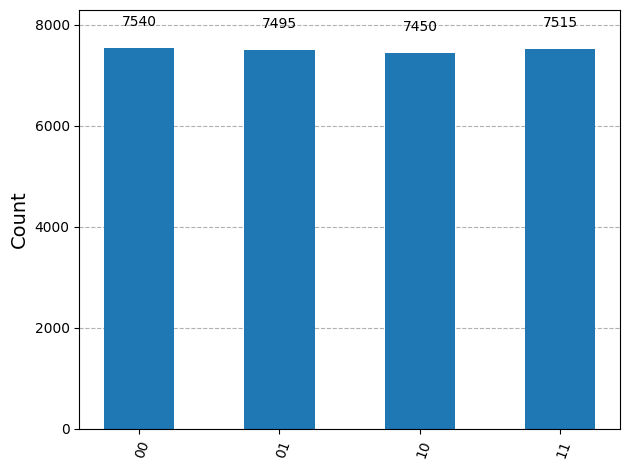

In [71]:
# This syntax allows you to run the job on a simulator, in case you have exhausted your allotted
# time on real IBM quantum computers.
# But we strongly advise running this on real quantum computers, since this is meant to be a check
# of the behavior of real quantum systems.

# This uses a local simulator
from qiskit_aer import AerSimulator

# This generates a simulator that mimics the real quantum system
backend_sim = AerSimulator.from_backend(backend)

# Import an estimator, this time from qiskit (we import from Runtime for real hardware)
from qiskit.primitives import BackendSamplerV2

sampler = BackendSamplerV2(backend=backend_sim)

result_list = [None] * len(qcs)
counts_list = [None] * len(qcs)
for i in range(0, len(qcs)):
    # Define the primitive unified bloc (pub)
    pub = qcs[i]
    job = sampler.run([pub], shots=10000)
    # Extract the result for the 0th pub (this example only has one pub).
    result_list[i] = job.result()
    data_pub = result_list[i][0].data
    counts = data_pub.c.get_counts()
    counts_list[i] = counts

data_pubs = (result_list[0][0].data, result_list[1][0].data, result_list[2][0].data)
outcomes = ("00", "01", "10", "11")

# Here we convert "None"s into 0's so that we can sum.

for i in range(0, len(qcs)):
    for j in range(0, len(outcomes)):
        if counts_list[i].get(outcomes[j]) is None:
            counts_list[i].update({outcomes[j]: 0})

# Here we create a dictionary that holds all the outcomes and sums over their appearances
# in each of the circuits.

total_counts = {}
for i in range(0, len(outcomes)):
    total_counts[outcomes[i]] = sum(
        counts_list[j].get(outcomes[i]) for j in range(0, len(qcs))
    )

print(total_counts)
plot_histogram(total_counts)
